### Import Data

In [2729]:
import pandas as pd
from datetime import datetime

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)



pretest_df = pd.read_csv("PRE-TEST.csv")
posttest_df = pd.read_csv("POST-TEST.csv")

today = pd.to_datetime("today")

def compute_age(row):
    age = row['age']
    dob = row['date_of_birth']
    
    # Use age if present
    if pd.notnull(age):
        return age
    
    # If DOB is missing, return None
    if pd.isnull(dob):
        return None
    
    dob_str = str(dob)
    
    # If DOB is just a year (e.g., "1995")
    if len(dob_str) == 4 and dob_str.isdigit():
        return today.year - int(dob_str)
    
    # If full date
    dob_date = pd.to_datetime(dob, errors='coerce')
    if pd.isnull(dob_date):
        return None
    
    return today.year - dob_date.year - (
        (today.month, today.day) < (dob_date.month, dob_date.day)
    )

def compute_generation(row):
    age = row['age_cleaned']

    generation = ""
    
    if age > 61:
        generation = "Baby Boomer"

    if age <= 61:
        generation = "Gen X"

    return generation
    

pretest_df['age_cleaned'] = pretest_df.apply(compute_age, axis=1)
pretest_df['generation'] = pretest_df.apply(compute_generation, axis=1)

pretest_df['gender'] = pretest_df['gender'].replace({
    'Lalaki': 'Male',
    'Babae': 'Female'
})

posttest_df['age_cleaned'] = posttest_df.apply(compute_age, axis=1)
posttest_df['generation'] = posttest_df.apply(compute_generation, axis=1)

posttest_df['gender'] = posttest_df['gender'].replace({
    'Lalaki': 'Male',
    'Babae': 'Female'
})

print(pretest_df.shape)
print(posttest_df.shape)

(210, 37)
(210, 28)


### Respondents per Barangay

In [2730]:
pretest_barangay_generation_counts = (
    pretest_df
    .groupby(['barangay', 'generation'])
    .size()
    .reset_index(name='respondents')
)

posttest_barangay_generation_counts = (
    posttest_df
    .groupby(['barangay', 'generation'])
    .size()
    .reset_index(name='respondents')
)
#print("Pre-Test")
#print(pretest_barangay_generation_counts)
#print("")
#print("Post-Test")
#print(posttest_barangay_generation_counts)


import pandas as pd

# Merge pre and post
comparison = pretest_barangay_generation_counts.merge(
    posttest_barangay_generation_counts,
    on=['barangay', 'generation'],
    how='outer',
    suffixes=('_pre', '_post')
)

# Fill missing values (if any) with 0
comparison[['respondents_pre', 'respondents_post']] = (
    comparison[['respondents_pre', 'respondents_post']].fillna(0).astype(int)
)

# Compute difference
comparison['difference'] = (
    comparison['respondents_post'] - comparison['respondents_pre']
)

# Sort for readability
comparison = comparison.sort_values(by=['barangay', 'generation']).reset_index(drop=True)

# Display as clean DataFrame
display(comparison)  # best for Jupyter / notebooks

# If not using Jupyter, use this instead:
# print(comparison.to_string(index=False))

# Total difference
print("\nTotal Difference:", comparison['difference'].sum())

,barangay,generation,respondents_pre,respondents_post,difference
0,Calauag,Baby Boomer,10,10,0
1,Calauag,Gen X,15,15,0
2,Cararayan,Baby Boomer,21,21,0
3,Cararayan,Gen X,33,33,0
4,Concepcion Grande,Baby Boomer,10,10,0
5,Concepcion Grande,Gen X,16,16,0
6,Concepcion Pequeña,Baby Boomer,25,25,0
7,Concepcion Pequeña,Gen X,37,37,0
8,Del Rosario,Baby Boomer,10,10,0
9,Del Rosario,Gen X,14,14,0



Total Difference: 0


### Reverse Code Necessary Items

In [2731]:
reverse_items = [
    'Q1','Q2','Q3',
    'Q9','Q10','Q11',
    'Q12',
    'Q19',
    'Q20','Q21','Q22','Q23'
]

# Reverse code questionnaire items
for col in reverse_items:
    pretest_df[col] = 6 - pretest_df[col]

# Reverse code SST item 3
pretest_df['SST_3'] = 8 - pretest_df['SST_3']


# Reverse code SST item 3
posttest_df['SST_3'] = 8 - pretest_df['SST_3']

### Replace Blanks with Mean

In [2732]:
# Columns to fill PRETEST
cols_to_fill = (
    [f'Q{i}' for i in range(1, 24)] +
    [f'SST_{i}' for i in range(1, 6)]
)

# Replace blank strings with NaN first
pretest_df[cols_to_fill] = pretest_df[cols_to_fill].replace(
    r'^\s*$',
    pd.NA,
    regex=True
)

# Convert columns to numeric
pretest_df[cols_to_fill] = pretest_df[cols_to_fill].apply(
    pd.to_numeric,
    errors='coerce'
)

# Fill missing values using overall column mean and round
for col in cols_to_fill:
    pretest_df[col] = pretest_df[col].fillna(
        pretest_df[col].mean().round()
    )

# Columns to fill POSTTEST
cols_to_fill = [f'SST_{i}' for i in range(1, 6)]

# Replace blank strings with NaN first
posttest_df[cols_to_fill] = posttest_df[cols_to_fill].replace(
    r'^\s*$',
    pd.NA,
    regex=True
)

# Convert columns to numeric
posttest_df[cols_to_fill] = posttest_df[cols_to_fill].apply(
    pd.to_numeric,
    errors='coerce'
)

# Fill missing values using overall column mean and round
for col in cols_to_fill:
    posttest_df[col] = posttest_df[col].fillna(
        posttest_df[col].mean().round()
    )

### Sex Demographics

#### Per Barangay

In [2733]:
gender_demographics = (
    pretest_df
    .groupby(['barangay', 'gender'])
    .size()
    .reset_index(name='respondents')
)

# Calculate percentage per barangay
gender_demographics['percentage'] = (
    gender_demographics['respondents'] /
    gender_demographics.groupby('barangay')['respondents'].transform('sum')
) * 100

# Optional: round percentage
gender_demographics['percentage'] = gender_demographics['percentage'].round(2)

gender_demographics

,barangay,gender,respondents,percentage
0,Calauag,Female,11,44.00
1,Calauag,Male,14,56.00
2,Cararayan,Female,33,61.11
3,Cararayan,Male,21,38.89
4,Concepcion Grande,Female,11,42.31
5,Concepcion Grande,Male,15,57.69
6,Concepcion Pequeña,Female,41,66.13
7,Concepcion Pequeña,Male,21,33.87
8,Del Rosario,Female,16,66.67
9,Del Rosario,Male,8,33.33


#### Sample Set

In [2734]:
# Count respondents per gender (no barangay grouping)
sex_counts = posttest_df.groupby('gender').size()
print(sex_counts)

print("")

# Metrics
total_respondents = sex_counts.sum()
mean_respondents = sex_counts.mean()
std_dev = sex_counts.std()

print("Total Respondents:", total_respondents)
print("Mean Respondents per Gender:", round(mean_respondents, 2))
print("Standard Deviation:", round(std_dev, 2))

# Proper describe
print(sex_counts.describe())

gender
Female    132
Male       78
dtype: int64

Total Respondents: 210
Mean Respondents per Gender: 105.0
Standard Deviation: 38.18
count      2.000000
mean     105.000000
std       38.183766
min       78.000000
25%       91.500000
50%      105.000000
75%      118.500000
max      132.000000
dtype: float64


### Educational Attainment

#### Per Baranggay

In [2735]:
educ_demographics = (
    pretest_df
    .groupby(['barangay', 'educ_attainment'])
    .size()
    .reset_index(name='respondents')
)

# Calculate percentage per barangay
educ_demographics['percentage'] = (
    educ_demographics['respondents'] /
    educ_demographics.groupby('barangay')['respondents'].transform('sum')
) * 100

# Optional: round percentage
educ_demographics['percentage'] = educ_demographics['percentage'].round(2)

educ_demographics

,barangay,educ_attainment,respondents,percentage
0,Calauag,College Level/College Graduate,16,64.00
1,Calauag,High School/Vocational,9,36.00
2,Cararayan,College Level/College Graduate,23,42.59
3,Cararayan,Elementary,8,14.81
4,Cararayan,High School/Vocational,21,38.89
5,Cararayan,Post-graduate,2,3.70
6,Concepcion Grande,College Level/College Graduate,14,53.85
7,Concepcion Grande,Elementary,2,7.69
8,Concepcion Grande,High School/Vocational,9,34.62
9,Concepcion Grande,Post-graduate,1,3.85


#### Sample Set

In [2736]:
educ_demographics = (
    pretest_df
    .groupby('educ_attainment')
    .size()
    .reset_index(name='respondents')
)

# Total respondents
total_respondents = educ_demographics['respondents'].sum()

# Percentage
educ_demographics['percentage'] = (
    educ_demographics['respondents'] / total_respondents
) * 100

educ_demographics['percentage'] = educ_demographics['percentage'].round(2)

# Standard deviation
std_dev = educ_demographics['respondents'].std()

print("Total Respondents:", total_respondents)
print("Standard Deviation:", round(std_dev, 2))
print(educ_demographics['respondents'].describe())

educ_demographics

Total Respondents: 210
Standard Deviation: 44.3
count      5.000000
mean      42.000000
std       44.300113
min        1.000000
25%        8.000000
50%       24.000000
75%       75.000000
max      102.000000
Name: respondents, dtype: float64


,educ_attainment,respondents,percentage
0,College Level/College Graduate,102,48.57
1,Elementary,24,11.43
2,High School/Vocational,75,35.71
3,Post-graduate,8,3.81
4,Walang Pormal na pag-aaral,1,0.48


### SOP 1

#### Factor Scores

In [2737]:
pretest_df['digital_literacy'] = pretest_df[['Q1','Q2','Q3']].mean(axis=1)

pretest_df['online_behavior'] = pretest_df[['Q4','Q5','Q6']].mean(axis=1)

pretest_df['trust_risk'] = pretest_df[['Q7','Q8']].mean(axis=1)

pretest_df['awareness'] = pretest_df[['Q9','Q10','Q11']].mean(axis=1)

pretest_df['social_factors'] = pretest_df[['Q12','Q13']].mean(axis=1)

pretest_df['financial_pressure'] = pretest_df[['Q14','Q15']].mean(axis=1)

pretest_df['attention_factors'] = pretest_df[['Q16','Q17']].mean(axis=1)

pretest_df['previous_exposure'] = pretest_df[['Q18','Q19']].mean(axis=1)

pretest_df['security_practices'] = pretest_df[['Q20','Q21','Q22','Q23']].mean(axis=1)


# Scam susceptibility score POST TEST
pretest_df['sst_total'] = posttest_df[
    ['SST_1','SST_2','SST_3','SST_4','SST_5']
].mean(axis=1)


# Scam susceptibility score POST TEST
posttest_df['sst_total'] = posttest_df[
    ['SST_1','SST_2','SST_3','SST_4','SST_5']
].mean(axis=1)


#### Cronbach's Alpha Function

In [2738]:
import numpy as np
import pandas as pd

def cronbach_alpha(df):
    df = df.dropna(axis=0)  # remove rows with missing values
    item_variances = df.var(axis=0, ddof=1)
    total_score = df.sum(axis=1)
    n_items = df.shape[1]

    total_variance = total_score.var(ddof=1)

    alpha = (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_variance)
    return alpha

In [2739]:
## Digital Literacy
digital_literacy = pretest_df[['Q1', 'Q2', 'Q3']]
print("Digital Literacy Alpha:", round(cronbach_alpha(digital_literacy), 3))

## Online Behavior
online_behavior = pretest_df[['Q4', 'Q5', 'Q6']]
print("Online Behavior Alpha:", round(cronbach_alpha(online_behavior), 3))

## Trust and Risk Perception
##trust_risk = pretest_df[['Q7', 'Q8']]
##print("Trust & Risk Alpha:", round(cronbach_alpha(trust_risk), 3))

## Awareness of Scam Types
awareness = pretest_df[['Q9', 'Q10', 'Q11']]
print("Awareness Alpha:", round(cronbach_alpha(awareness), 3))

## Social Factors
##social = pretest_df[['Q12', 'Q13']]
##print("Social Factors Alpha:", round(cronbach_alpha(social), 3))

## Financial Pressure
##financial = pretest_df[['Q14', 'Q15']]
##print("Financial Pressure Alpha:", round(cronbach_alpha(financial), 3))

## Attention Factors
##attention = pretest_df[['Q16', 'Q17']]
##print("Attention Factors Alpha:", round(cronbach_alpha(attention), 3))

## Previous Exposure
##exposure = pretest_df[['Q18', 'Q19']]
##print("Previous Exposure Alpha:", round(cronbach_alpha(exposure), 3))

## Security Practices
security = pretest_df[['Q20', 'Q21', 'Q22', 'Q23']]
print("Security Practices Alpha:", round(cronbach_alpha(security), 3))

Digital Literacy Alpha: 0.772
Online Behavior Alpha: 0.487
Awareness Alpha: 0.749
Security Practices Alpha: 0.741


#### Pearson r

In [2740]:
from scipy.stats import pearsonr

factors = [
    'digital_literacy',
    'online_behavior',
    'trust_risk',
    'awareness',
    'social_factors',
    'financial_pressure',
    'attention_factors',
    'previous_exposure',
    'security_practices'
]

for factor in factors:
    r, p = pearsonr(pretest_df[factor], pretest_df['sst_total'])

    print(f'\n{factor}')
    print(f'Correlation (r): {round(r,3)}')
    print(f'P-value: {round(p,5)}')



digital_literacy
Correlation (r): -0.077
P-value: 0.2687

online_behavior
Correlation (r): 0.041
P-value: 0.55489

trust_risk
Correlation (r): 0.125
P-value: 0.07153

awareness
Correlation (r): -0.089
P-value: 0.199

social_factors
Correlation (r): 0.014
P-value: 0.8404

financial_pressure
Correlation (r): -0.036
P-value: 0.5993

attention_factors
Correlation (r): 0.006
P-value: 0.9259

previous_exposure
Correlation (r): -0.05
P-value: 0.46831

security_practices
Correlation (r): -0.055
P-value: 0.42668


#### Multiple Linear Regression

In [2741]:
import statsmodels.api as sm

X = pretest_df[factors]

y = pretest_df['sst_total']

# Add constant
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              sst_total   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                    0.6873
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.720
Time:                        15:22:06   Log-Likelihood:                -319.52
No. Observations:                 210   AIC:                             659.0
Df Residuals:                     200   BIC:                             692.5
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  3.2713      0

### SOP 2

#### Shapiro-Wik Test

In [2742]:
from scipy.stats import shapiro

print(shapiro(male))
print(shapiro(female))

print("\nShapiro–Wilk tests indicated that the data for both groups were not normally distributed (p < .001)." )
print("However, given the large sample sizes, the Independent Samples t-test was still employed, as it is robust to violations of normality.")

ShapiroResult(statistic=np.float64(0.9660869952167339), pvalue=np.float64(0.01989198302074725))
ShapiroResult(statistic=np.float64(0.9223801684235263), pvalue=np.float64(3.052724383663168e-06))

Shapiro–Wilk tests indicated that the data for both groups were not normally distributed (p < .001).
However, given the large sample sizes, the Independent Samples t-test was still employed, as it is robust to violations of normality.


#### Independent Samples T-Test Sex

In [2743]:
from scipy.stats import ttest_ind

# Assuming your dataframe has:
# column for gender (e.g. 'gender')
# column for vulnerability score (e.g. 'vulnerability_score')

male = pretest_df[pretest_df['gender'] == 'Male']['sst_total']
female = pretest_df[pretest_df['gender'] == 'Female']['sst_total']

t_stat, p_value = ttest_ind(male, female, equal_var=False)  # Welch's t-test

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Significant difference between male and female older adults.")
else:
    print("No significant difference between male and female older adults.")

T-statistic: 0.32348070204464724
P-value: 0.746688439594672
No significant difference between male and female older adults.


#### Educational Attainment - Remove 1 No Formal Schooling

In [2744]:
anova_df = pretest_df[
    pretest_df['educ_attainment'] != 'Walang Pormal na pag-aaral'
]

#### Welch's ANOVA

In [2745]:
import pingouin as pg

welch = pg.welch_anova(
    dv='sst_total',
    between='educ_attainment',
    data=anova_df
)

print(welch)

            Source  ddof1      ddof2         F     p_unc       np2
0  educ_attainment      3  29.051718  0.735469  0.539373  0.009712


p = 0.539 > 0.05 


Welch’s ANOVA revealed no statistically significant difference in scam susceptibility across educational attainment levels, F(3, 29.05) = 0.735, p = 0.539.


Educational attainment was not found to significantly influence scam susceptibility among older adults in the study sample. The effect size was very small, indicating minimal practical contribution of educational attainment to variations in scam vulnerability.

### SOP 3

#### Per Generation

In [2746]:
result = (
    posttest_df
    .groupby('generation')[['print_media', 'radio_ads', 'social_media']]
    .agg(
        print_media_yes=('print_media', lambda x: (x == 'Yes').sum()),
        print_media_no=('print_media', lambda x: (x == 'No').sum()),
        radio_ads_yes=('radio_ads', lambda x: (x == 'Yes').sum()),
        radio_ads_no=('radio_ads', lambda x: (x == 'No').sum()),
        social_media_yes=('social_media', lambda x: (x == 'Yes').sum()),
        social_media_no=('social_media', lambda x: (x == 'No').sum()),
    )
    .reset_index()
)

print(result.to_string(index=False))

 generation  print_media_yes  print_media_no  radio_ads_yes  radio_ads_no  social_media_yes  social_media_no
Baby Boomer                5              79             37            47                36               48
      Gen X                9             117             52            74                91               35


#### Transform to Long Format

In [2747]:
# Add Respondent ID
posttest_df = posttest_df.copy()
posttest_df['respondent_no'] = range(1, len(posttest_df) + 1)

# Effectiveness for Print Media
posttest_df['print_effectiveness'] = posttest_df[
    [
        'print_media_q1',
        'print_media_q2',
        'print_media_q3',
        'print_media_q4'
    ]
].mean(axis=1)

# Effectivieness for Radio Ads
posttest_df['radio_effectiveness'] = posttest_df[
    [
        'radio_ads_q1',
        'radio_ads_q2',
        'radio_ads_q3',
        'radio_ads_q4'
    ]
].mean(axis=1)

# Effectivieness for Social Media
posttest_df['social_effectiveness'] = posttest_df[
    [
        'social_media_q1',
        'social_media_q2',
        'social_media_q3',
        'social_media_q4'
    ]
].mean(axis=1)

In [2748]:
## Long Format

long_df = pd.melt(
    posttest_df,
    id_vars=['respondent_no', 'generation'],
    value_vars=[
        'print_effectiveness',
        'radio_effectiveness',
        'social_effectiveness'
    ],
    var_name='strategy',
    value_name='effectiveness'
)

long_df = long_df.dropna(subset=['effectiveness'])

#### Mixed Model

In [2749]:
## Mixed Model

import statsmodels.formula.api as smf

model = smf.mixedlm(
    'effectiveness ~ strategy * generation',
    data=long_df,
    groups=long_df['respondent_no']
)

result = model.fit()

print(result.summary())

                             Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             effectiveness
No. Observations:             231                 Method:                         REML         
No. Groups:                   157                 Scale:                          0.1628       
Min. group size:              1                   Log-Likelihood:                 -270.4514    
Max. group size:              3                   Converged:                      Yes          
Mean group size:              1.5                                                              
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                             3.990    0.259 

We cannot treat #not reached as low effectiveness because they never meaningfully experienced the strategy.

Intercept: β = 3.990, p < 0.001

This is the baseline effectiveness score for the reference group:
Print media (reference category), Reference generation (Baby Boomers)

Radio effectiveness is 0.027 lower than print media (not significant)

Social media effectiveness is 0.101 lower than print media (not significant)


Generation (Gen X vs Baby Boomers)
Gen X	-0.134	0.679
Interpretation:

There is no significant difference in overall perceived effectiveness between Gen X and Baby Boomers.

Meaning
Generations respond similarly overall. No general generational bias in effectiveness ratings


The relative effectiveness of print, radio, and social media does NOT differ across generations. This means that Boomers and Gen X perceive strategies similarly, no strategy is uniquely better for a specific generation


Group variance = 0.661 which means there is moderate variability in effectiveness ratings between individuals.

This means that respondents differ in their perceptions but this variation is NOT explained by strategy or generation.

#### Pairwise Test

In [2750]:
# Pairwise Test

import pingouin as pg

pg.pairwise_tests(
    dv='effectiveness',
    within='strategy',
    between='generation',
    subject='respondent_no',
    data=long_df,
    padjust='bonf'
)

,Contrast,strategy,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,strategy,-,print_effectiveness,radio_effectiveness,True,True,0.000000,4.000000,two-sided,1.000000,1.000000,bonf,0.397,0.000000
1,strategy,-,print_effectiveness,social_effectiveness,True,True,0.514496,4.000000,two-sided,0.634027,1.000000,bonf,0.443,0.242361
2,strategy,-,radio_effectiveness,social_effectiveness,True,True,0.337526,4.000000,two-sided,0.752689,1.000000,bonf,0.417,0.221244
3,generation,-,Baby Boomer,Gen X,False,True,-3.605551,1.898876,two-sided,0.074536,NaN,NaN,2.393,-2.526834
4,strategy * generation,print_effectiveness,Baby Boomer,Gen X,False,True,-3.050851,1.898876,two-sided,0.098810,0.296429,bonf,1.93,-2.138090
5,strategy * generation,radio_effectiveness,Baby Boomer,Gen X,False,True,-1.408406,2.596650,two-sided,0.266838,0.800513,bonf,0.917,-0.762770
6,strategy * generation,social_effectiveness,Baby Boomer,Gen X,False,True,-1.356748,2.234116,two-sided,0.295662,0.886986,bonf,0.895,-0.711447


The model suggests that communication strategy doesn’t meaningfully change perceived effectiveness. There is a possible (but not conclusive) indication that Gen X rates effectiveness higher than Baby Boomers, and that this difference might be slightly more visible for print media, but none of these effects are strong enough to be considered statistically reliable after correction.

### Reach per Strategy

In [2751]:
reach_table = posttest_df.copy()

# Convert Yes/No to 1/0
cols = ['print_media', 'radio_ads', 'social_media']

reach_table[cols] = reach_table[cols].map(lambda x: 1 if x == 'Yes' else 0 if x == 'No' else None)

# Group and compute percentage reach
reach_table = reach_table.groupby('generation').agg({
    'print_media': 'mean',
    'radio_ads': 'mean',
    'social_media': 'mean'
}) * 100

reach_table = reach_table.round(2)

print(reach_table)

             print_media  radio_ads  social_media
generation                                       
Baby Boomer         5.95      44.05         42.86
Gen X               7.14      41.27         72.22


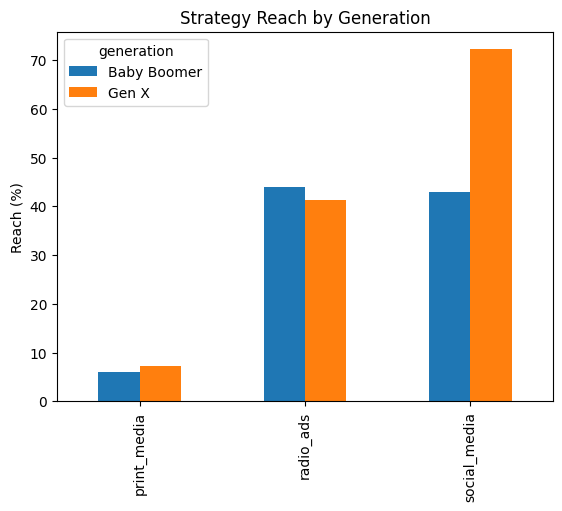

In [2752]:
import matplotlib.pyplot as plt

reach_table.T.plot(kind='bar')
plt.ylabel('Reach (%)')
plt.title('Strategy Reach by Generation')
plt.show()

### SOP 4

In [2757]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.shapiro(pretest_df['sst_total'])
stats.shapiro(posttest_df['sst_total'])

ShapiroResult(statistic=np.float64(0.9452760176976621), pvalue=np.float64(3.882649316239508e-07))

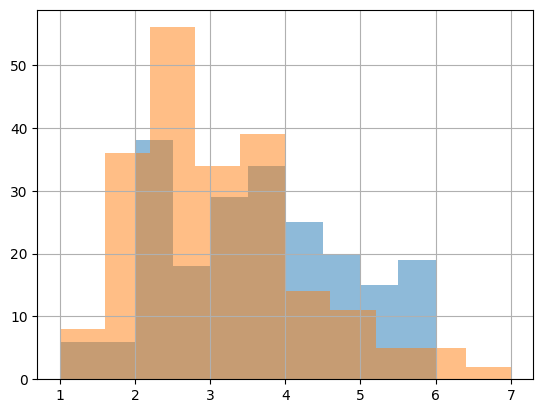

In [2758]:
pretest_df['sst_total'].hist(alpha=0.5)
posttest_df['sst_total'].hist(alpha=0.5)
plt.show()

#### Independent Samples t-test

In [2755]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# -----------------------------
# 1. Create vulnerability score (if not yet created)
# Replace item1–item5 with your actual column names
# -----------------------------
likert_items = ['SST_1', 'SST_2', 'SST_3', 'SST_4', 'SST_5']

posttest_df['sst_total'] = posttest_df[likert_items].mean(axis=1)
pretest_df['sst_total'] = pretest_df[likert_items].mean(axis=1)

# -----------------------------
# 2. Extract scores
# -----------------------------
pre_scores = pretest_df['sst_total'].dropna()
post_scores = posttest_df['sst_total'].dropna()

# -----------------------------
# 3. Independent Samples t-test (Welch's t-test)
# -----------------------------
t_stat, p_value = ttest_ind(pre_scores, post_scores, equal_var=False)

print("Independent Samples t-test")
print("t-statistic:", t_stat)
print("p-value:", p_value)

# -----------------------------
# 4. Cohen's d function
# -----------------------------
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) 
        / (nx + ny - 2)
    )
    return (np.mean(x) - np.mean(y)) / pooled_sd

# -----------------------------
# 5. Effect size
# -----------------------------
d = cohens_d(pre_scores, post_scores)

print("\nCohen's d:", d)

# -----------------------------
# 6. Interpretation helper
# -----------------------------
alpha = 0.05

if p_value < alpha:
    print("\nResult: Significant difference between pretest and posttest.")
else:
    print("\nResult: No significant difference between pretest and posttest.")

# Effect size interpretation
if abs(d) < 0.2:
    effect = "negligible"
elif abs(d) < 0.5:
    effect = "small"
elif abs(d) < 0.8:
    effect = "medium"
else:
    effect = "large"

print("Effect size interpretation:", effect)

Independent Samples t-test
t-statistic: 4.96031729663584
p-value: 1.0275788028398828e-06

Cohen's d: 0.4840774011634787

Result: Significant difference between pretest and posttest.
Effect size interpretation: small


There is a statistically significant difference in scam vulnerability between the pretest and posttest groups (t = 4.96, p < .001). The effect size indicates a small-to-moderate practical difference (d = 0.48), suggesting that exposure to the prevention strategies had a measurable impact on scam vulnerability levels.

In [2756]:
# Calculate means
pre_mean = pretest_df['sst_total'].mean()
post_mean = posttest_df['sst_total'].mean()

# Display results
print(f"Pre-test mean (sst_total): {pre_mean:.4f}")
print(f"Post-test mean (sst_total): {post_mean:.4f}")

Pre-test mean (sst_total): 3.5867
Post-test mean (sst_total): 3.0200
